## Data Preprocessing

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Modeling imports
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    label_binarize,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
#Loading final merged dataset
restaurants = pd.read_csv("/Users/pdeguz01/Documents/git/Data/IDS705_Final/Working Dataset/MOST RECENT DATA/restauranthealthinspections2024_CensusSVIUSDA_halfmileradius.csv")
#restaurants


### Data Preprocessing


In [3]:
# encoding datetime information before training model
restaurants["INSPECTION_DATE"] = restaurants["INSPECTION_DATE"].astype("datetime64[ns]")
restaurants["INSPDATE_MONTH"] = restaurants["INSPECTION_DATE"].dt.month
restaurants["INSPDATE_DAY"] = restaurants["INSPECTION_DATE"].dt.day
#restaurants

In [4]:
# removings schools from our dataset
restaurants = restaurants[
    ~restaurants["STORE_NAME"].str.contains("SCHOOL", case=False, na=False)
]
len(restaurants)

47820

In [5]:
#make a SVI category that is quartiles
restaurants['SVIranking_quartile'] = pd.cut(
    restaurants['RPL_THEMES'],
    bins=[0, 0.25, 0.5, 0.75, 1],
    labels=[1, 2, 3, 4],
    include_lowest=True
)

In [6]:
#print counts by quartile
print(restaurants["SVIranking_quartile"].value_counts())

SVIranking_quartile
4    17529
3     9790
2     7592
1     5039
Name: count, dtype: int64


In [7]:
# subsetting to only CA
CA_restaurants = restaurants[restaurants["State"] == "CA"]
#CA_restaurants

# Handling Features with NAN values for a substantial number of rows

In [8]:
# dropping columns with 85% NAN
CA_restaurants = CA_restaurants.dropna(thresh=(int(len(CA_restaurants) * 0.15)), axis=1)
print(f"Number of columns after dropping 85% NAN: {len(CA_restaurants.columns)}")

Number of columns after dropping 85% NAN: 208


In [9]:
# dropping rows with NAN values
print("CA dataset before NAN dropping:", len(CA_restaurants))
CA_restaurants = CA_restaurants.dropna()
print("CA dataset after NAN dropping:", len(CA_restaurants))

CA dataset before NAN dropping: 34289
CA dataset after NAN dropping: 19160


In [10]:

# dropping EP_POV150 since it would likely be collinear with the other variables
CA_restaurants = CA_restaurants.drop(columns=["EP_POV150"])

In [11]:
# pulling 20% of this dataset for our test
CA_restaurant_test = CA_restaurants.sample(frac=0.2, random_state=42)
# drop these 20% pulled from our training set
CA_restaurants = CA_restaurants.drop(CA_restaurant_test.index)

In [12]:
# creating training dataset from subset of restaurants dataset (using grades)
CA_restaurant_model_grades = CA_restaurants[
    [
        "INSPDATE_YEAR",
        "INSPDATE_MONTH",
        "INSPDATE_DAY",
        "EP_UNEMP",
        "EP_HBURD",
        "EP_NOHSDP",
        "EP_UNINSUR",
        "EP_AGE65",
        "EP_AGE17",
        "EP_DISABL",
        "EP_SNGPNT",
        "EP_LIMENG",
        "EP_MINRTY",
        "EP_MUNIT",
        "EP_MOBILE",
        "EP_CROWD",
        "EP_NOVEH",
        "EP_GROUPQ",
        "USDA_PovertyRate",
        "USDA_MedianFamilyIncome",
        "USDA_PCTGQTRS",
        "GRADE",
    ]
]

# appending all columns with "share" in the column name
CA_share_cols = CA_restaurants[CA_restaurants.filter(like="share").columns]
CA_restaurant_model_grades = pd.concat(
    [CA_restaurant_model_grades, CA_share_cols],
    axis=1,
)
# resetting index
CA_restaurant_model_grades.reset_index(drop=True, inplace=True)
CA_restaurant_model_grades.head(10)

,INSPDATE_YEAR,INSPDATE_MONTH,INSPDATE_DAY,EP_UNEMP,EP_HBURD,EP_NOHSDP,EP_UNINSUR,EP_AGE65,EP_AGE17,EP_DISABL,...,USDA_laseniorshalfshare,USDA_lawhitehalfshare,USDA_lablackhalfshare,USDA_laasianhalfshare,USDA_lanhopihalfshare,USDA_laaianhalfshare,USDA_laomultirhalfshare,USDA_lahisphalfshare,USDA_lahunvhalfshare,USDA_lasnaphalfshare
0,2024,1,2,7.2,54.6,34.3,13.3,11.1,28.6,11.5,...,3.189273,27.795663,0.251159,1.405884,0.071399,0.714946,22.303396,49.148855,6.778290,8.554847
1,2024,1,2,6.2,25.0,0.9,1.1,45.2,11.1,13.2,...,36.100589,63.863004,0.781727,7.466659,0.082372,0.055858,2.121825,2.570727,5.833808,0.000000
2,2024,1,2,12.2,45.5,45.4,16.8,15.3,30.8,14.0,...,1.043259,6.616906,5.671133,0.000000,0.001440,0.117997,6.356435,12.496156,3.557535,6.677187
3,2024,1,2,7.6,43.7,21.3,19.4,9.7,15.8,14.5,...,1.197753,6.651286,1.088966,1.355553,0.009304,0.092756,5.800791,8.532187,4.234097,1.658559
4,2024,1,2,15.8,38.6,12.9,5.3,24.7,20.1,14.8,...,10.500454,24.264871,0.831529,20.616008,0.025272,0.195036,9.605363,17.878311,1.908538,0.898773
5,2024,1,2,6.8,38.0,9.1,6.2,14.5,15.2,13.3,...,0.045275,0.494731,0.046911,0.045222,0.000000,0.008256,0.213618,0.407727,0.021723,0.030244
6,2024,1,2,3.4,22.8,6.7,1.2,16.8,20.4,4.0,...,2.778117,14.147137,0.580954,1.735647,0.092601,0.209792,1.679366,3.311920,1.990631,0.835617
7,2024,1,2,3.4,22.8,6.7,1.2,16.8,20.4,4.0,...,2.778117,14.147137,0.580954,1.735647,0.092601,0.209792,1.679366,3.311920,1.990631,0.835617
8,2024,1,2,4.8,33.2,17.7,4.1,27.7,18.5,9.7,...,0.182087,0.450568,0.004128,0.620278,0.000000,0.000000,0.229532,0.440741,0.006089,0.098979
9,2024,1,2,3.7,22.7,15.9,8.2,16.4,23.8,10.3,...,6.997303,35.892672,2.853882,5.607811,0.702314,0.335196,18.501895,35.097219,0.867232,3.239686


# Exploring Social Vulnerability Index Rankings

Social Vulnerability Index Methodology Note: https://svi.cdc.gov/map25/data/docs/SVI2022Documentation_ZCTA.pdf
- "Overall tract rankings: We summed the sums for each theem, ordered the tracts, and then calculated overall percentile rankings."
- "The overall summary ranking variable is RPL_THEMES."


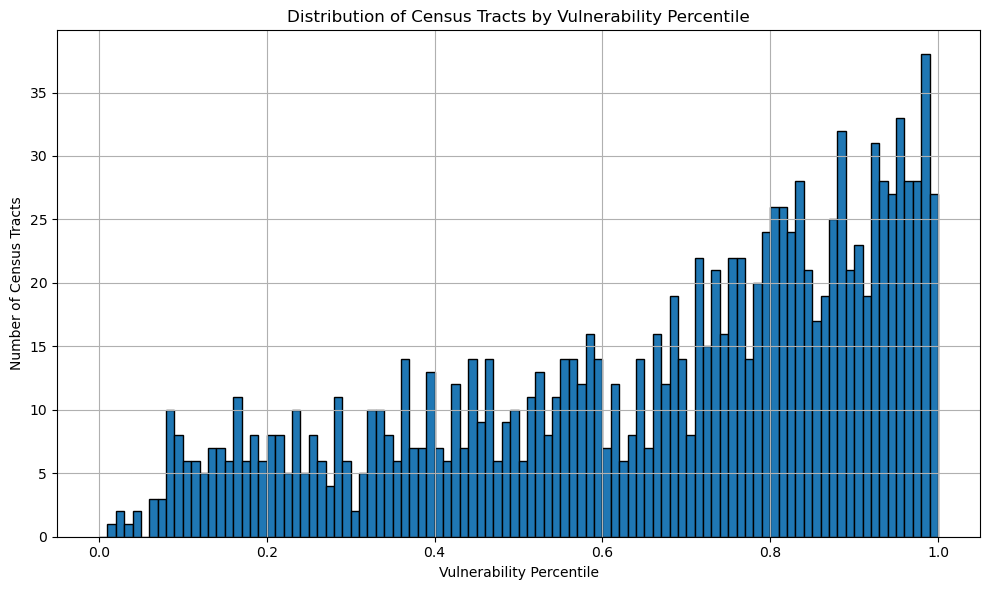

In [13]:
#Creating histogram of vulnerability score

#group by census tract
tracts = CA_restaurants[['PRIMARY_CENSUSTRACT', 'RPL_THEMES']].drop_duplicates()

#plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(tracts['RPL_THEMES'], bins=100, range=(0,1), edgecolor='black')
plt.title('Distribution of Census Tracts by Vulnerability Percentile')
plt.xlabel('Vulnerability Percentile')
plt.ylabel('Number of Census Tracts')
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
bin_edges = list(range(0, 105, 5))  # [0, 5, 10, ..., 100]
bin_labels = [f'{i}-{i+5}th' for i in range(0, 100, 5)]  # ['0-5th', '5-10th', ..., '95-100th']

# Convert percentiles to 0–100 scale and assign to bins (10th, 20th, ..., 100th)
tracts['percentile_bin'] = pd.cut(
    tracts['RPL_THEMES'] * 100,
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
    right=False  # To include lower bound, exclude upper
)

# Count number of census tracts in each bin
bin_counts = tracts['percentile_bin'].value_counts().sort_index()

# Optional: convert to a DataFrame for easier viewing or exporting
bin_counts_df = bin_counts.reset_index()
bin_counts_df.columns = ['Percentile Bin', 'Number of Census Tracts']

# Display result
print(bin_counts_df)

   Percentile Bin  Number of Census Tracts
0           0-5th                        6
1          5-10th                       24
2         10-15th                       31
3         15-20th                       37
4         20-25th                       36
5         25-30th                       35
6         30-35th                       35
7         35-40th                       47
8         40-45th                       46
9         45-50th                       48
10        50-55th                       49
11        55-60th                       70
12        60-65th                       47
13        65-70th                       68
14        70-75th                       82
15        75-80th                      102
16        80-85th                      125
17        85-90th                      114
18        90-95th                      128
19       95-100th                      154


# Train/test split for Grade Dataset

In [15]:
# X = restaurant_model_grades[[i for i in list(restaurant_model_grades.columns) if i != "GRADE"]]
X = CA_restaurant_model_grades.drop("GRADE", axis=1)
y = CA_restaurant_model_grades[["GRADE"]]

# encoding target labels (A, B, C -> 0, 1, 2)
target_label = LabelEncoder()
y_encoded = target_label.fit_transform(y)
# binarize labels/one-hot encoding (needed for one-vs-rest when calculating ROC/AUC and PR curve)
y_bin = label_binarize(y_encoded, classes=[0, 1, 2])
# num_classes = len(pd.unique(y["GRADE"]))
num_classes = y_bin.shape[1]

# train/test split
X_train_grade, X_test_grade, y_train_grade, y_test_grade = train_test_split(
    X, y_bin, test_size=0.3, random_state=42
)





In [16]:
#Scaling data
# normalizing our data using our MinMaxScaler
# transforms each value in the col proportionally within [0,1]
scaler = MinMaxScaler()
X_train_grade_scaled = scaler.fit_transform(X_train_grade)
X_test_grade_scaled = scaler.fit_transform(X_test_grade)
# scaler = StandardScaler()

# Training Multinomial Logistic Regression Model

In [17]:
# ABOUT THE LOGISTIC REGRESSION MODEL:
# creating multinomial logistic regression model
# testing other solvers, but apparently, 'lbfgs' is "great for multinomial"
# liblinear only handles binary classification, so we'll test for that later
# doing l2 penalty b/c only liblinear is compatible with l1 and l2

# ABOUT THE OneVsRestClassifier:
# Fits one classifier, LR in this case, per class, used in multiclass logistic regression
# will help us calculate ROC/AUC score and PR for each class relative to the others
# this is why we binarized the labels (e.g. for class A, the negative class is class B and C)
# aka we are translating multinomial log reg = multiple binary classification tasks, one per class
LR = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
    )
)

In [18]:
LR.fit(X_train_grade_scaled, y_train_grade)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 multi_class='multinomial'))

In [19]:
# predicting confidence scores
LR_y_pred = LR.predict_proba(X_test_grade_scaled)


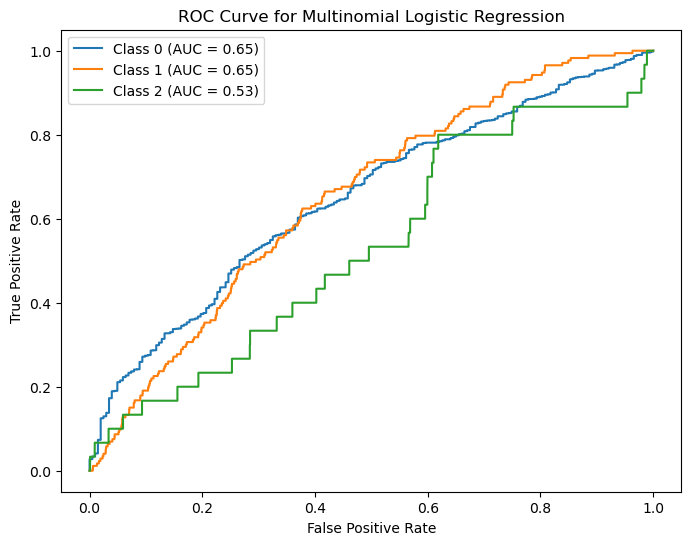

In [20]:
# the way we plotted AUC/PR curves in class is not
# supported for multiclass...doing it another way
import matplotlib.pyplot as plt
from sklearn.metrics import (
    auc,
    average_precision_score,
    mean_squared_error,
    precision_recall_curve,
    r2_score,
    roc_curve,
)

# plotting ROC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_grade[:, i], LR_y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
# plot ROC curve for a specific class
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multinomial Logistic Regression")
plt.legend()
plt.show()

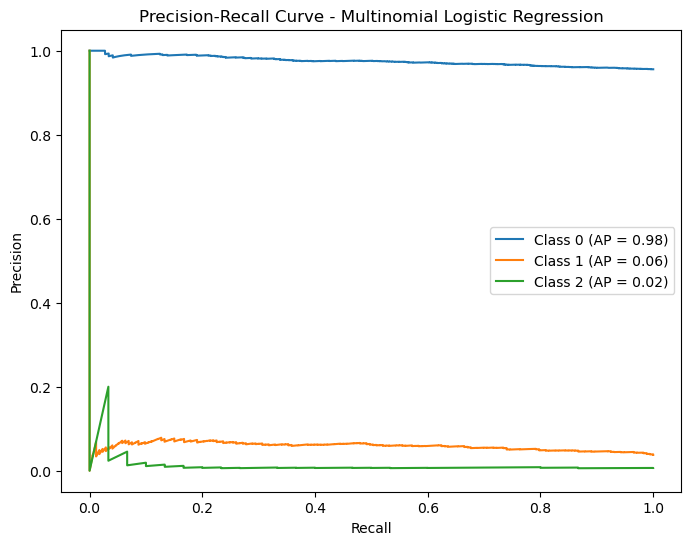

In [21]:
# plotting our PR curves for each class
precision = dict()
recall = dict()
avg_precision = dict()

# plotting each PR curve
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_grade[:, i], LR_y_pred[:, i]
    )
    avg_precision[i] = average_precision_score(y_test_grade[:, i], LR_y_pred[:, i])
    plt.plot(recall[i], precision[i], label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Multinomial Logistic Regression")
plt.legend()
plt.show()

# Testing Multinomial Logistic Regression Model on High Social Vulnerability Dataset

In [22]:
#Merging model predictions back into dataset to analyze model performance across different SVI groupings


In [23]:
LR_y_pred_labels = LR.predict(X_test_grade_scaled)


In [24]:
LR_y_pred_labels_actual = target_label.inverse_transform(np.argmax(LR_y_pred_labels, axis=1))


In [25]:
# Make a dataframe out of X_test
X_test_df = pd.DataFrame(X_test_grade_scaled, columns=X.columns)

# Add true and predicted labels
X_test_df["true_grade_encoded"] = np.argmax(y_test_grade, axis=1)  # because y_test_grade is one-hot encoded
X_test_df["true_grade"] = target_label.inverse_transform(X_test_df["true_grade_encoded"])
X_test_df["predicted_grade_encoded"] = np.argmax(LR_y_pred, axis=1)
X_test_df["predicted_grade"] = target_label.inverse_transform(X_test_df["predicted_grade_encoded"])


In [26]:
# First, match the index
CA_restaurant_test_reindexed = CA_restaurant_test.reset_index(drop=True)

# Now merge
X_test_full = pd.concat([CA_restaurant_test_reindexed, X_test_df[["true_grade", "predicted_grade"]]], axis=1)


In [27]:
print(X_test_full.columns.tolist())

['INSPECTION_DATE', 'STORE_NAME', 'STREET_ADDRESS', 'CITY', 'ZIP5', 'SERVICE_DESCRIPTION', 'SCORE', 'GRADE', 'INSPDATE_YEAR', 'Latitude', 'Longitude', 'Accuracy Score', 'Accuracy Type', 'Number', 'Street', 'City', 'State', 'County', 'Zip', 'Country', 'Source', 'geometry', 'buffer', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'PRIMARY_CENSUSTRACT', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'AVG_INCOME_NEARBY_TRACTS', 'AVG_HH_SIZE_NEARBY_TRACTS', 'AVG_RENT_NEARBY_TRACTS', 'AVG_POP_NEARBY_TRACTS', 'ST_ABBR', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'E_HU', 'E_HH', 'E_POV150', 'E_UNEMP', 'E_HBURD', 'E_NOHSDP', 'E_UNINSUR', 'E_AGE65', 'E_AGE17', 'E_DISABL', 'E_SNGPNT', 'E_LIMENG', 'E_MINRTY', 'E_MUNIT', 'E_MOBILE', 'E_CROWD', 'E_NOVEH', 'E_GROUPQ', 'EP_UNEMP', 'EP_HBURD', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_LIMENG', 'EP_MINRTY', 'EP_MUNIT', 'EP_MOBILE', 'EP_CROWD', 'EP_NOVEH', 'EP_GROUPQ', 'EPL_POV150', 'EPL

In [28]:
X_test_full["correct_prediction"] = (X_test_full["true_grade"] == X_test_full["predicted_grade"])

# Group by SVIranking_quartile and calculate accuracy
performance_by_pov = X_test_full.groupby("SVIranking_quartile")["correct_prediction"].mean()

print(performance_by_pov)


SVIranking_quartile
1    0.446328
2    0.413043
3    0.379147
4    0.387078
Name: correct_prediction, dtype: float64


In [29]:
# Reporting Results

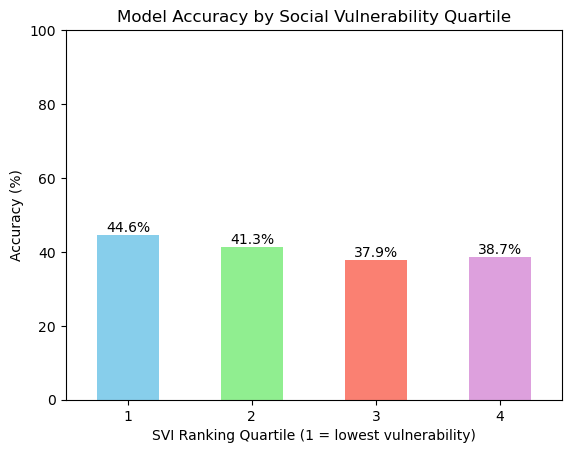

In [30]:
import matplotlib.pyplot as plt

# Define a color for each bar
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

# Multiply the values by 100 to show as percentages
performance_by_pov_percent = performance_by_pov * 100

ax = performance_by_pov_percent.plot(kind='bar', color=colors)

plt.xlabel('SVI Ranking Quartile (1 = lowest vulnerability)')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy by Social Vulnerability Quartile')
plt.ylim(0, 100)  # y-axis between 0 and 100
plt.xticks(rotation=0)

# Add numbers above the bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',  # already in percent
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()


In [31]:
# Simple post-hoc chi-squared test to see if the differences by SVI quartile are statistically significant. they don't appear to be.

import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table: rows = SVI quartiles, columns = correct vs incorrect
contingency_table = pd.crosstab(X_test_full["SVIranking_quartile"], X_test_full["correct_prediction"])

# Run chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-squared statistic: {chi2:.3f}")
print(f"p-value: {p:.4f}")


Chi-squared statistic: 6.454
p-value: 0.0915
